In [ ]:
Atividades Práticas Experimentais:
Abra o arquivo “pdi26__lab7__morph_.ipynb”, no Jupyter Notebook.
Estude detalhadamente todas as funções fornecidas e os códigos.
Elabore seu código de programa para cada realizar cada uma das atividades propostas.

In [ ]:
(3.a). Elabore um programa para realizar as operações de EROSÃO, DILATAÇÃO, ABERTURA,
e FECHAMENTO, sobre as imagens em grupo dos integrantes da equipe bem como nos
avatares, e apresente os resultados. Elabore uma análise detalhada de cada imagem,
experimentado diversos tamanhos (3x3 até 21x21) de Elemento Estruturante – KERNEL - e
compare-as entre si, quanto ao aspecto visual (filtragem, aparência, representação, etc) da
imagens resultantes. Lembre-se de binarizar as imagens antes da aplicação dos
operadores. Assim, dentro desta análise, discuta se a binarização influiu no resultado e
qual método foi mais interessante para sua aplicação.

=== EROSÃO ===


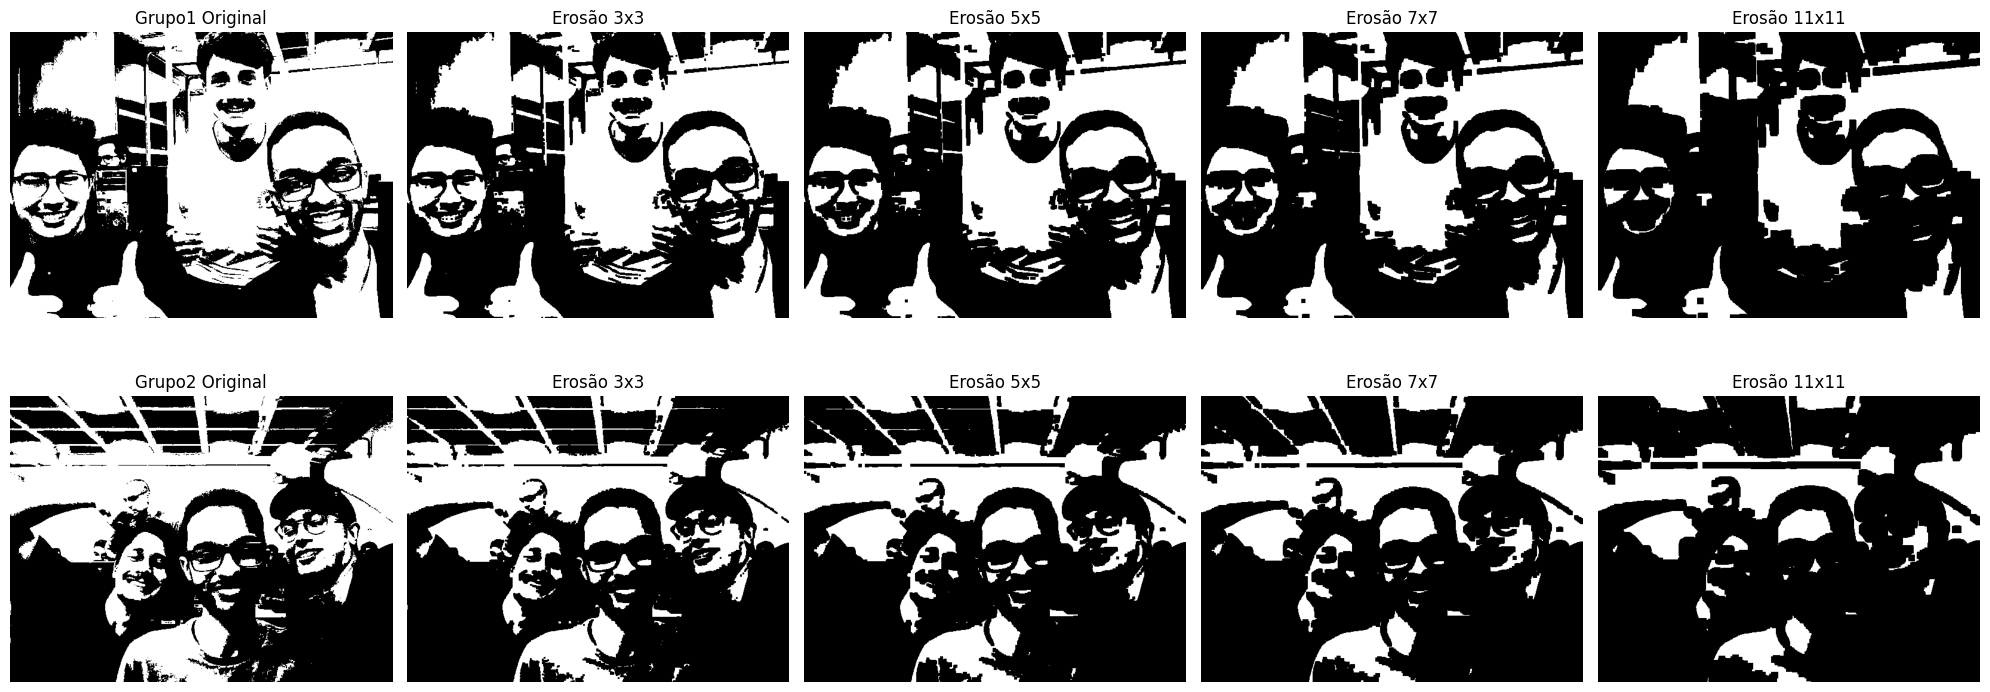

=== DILATAÇÃO ===


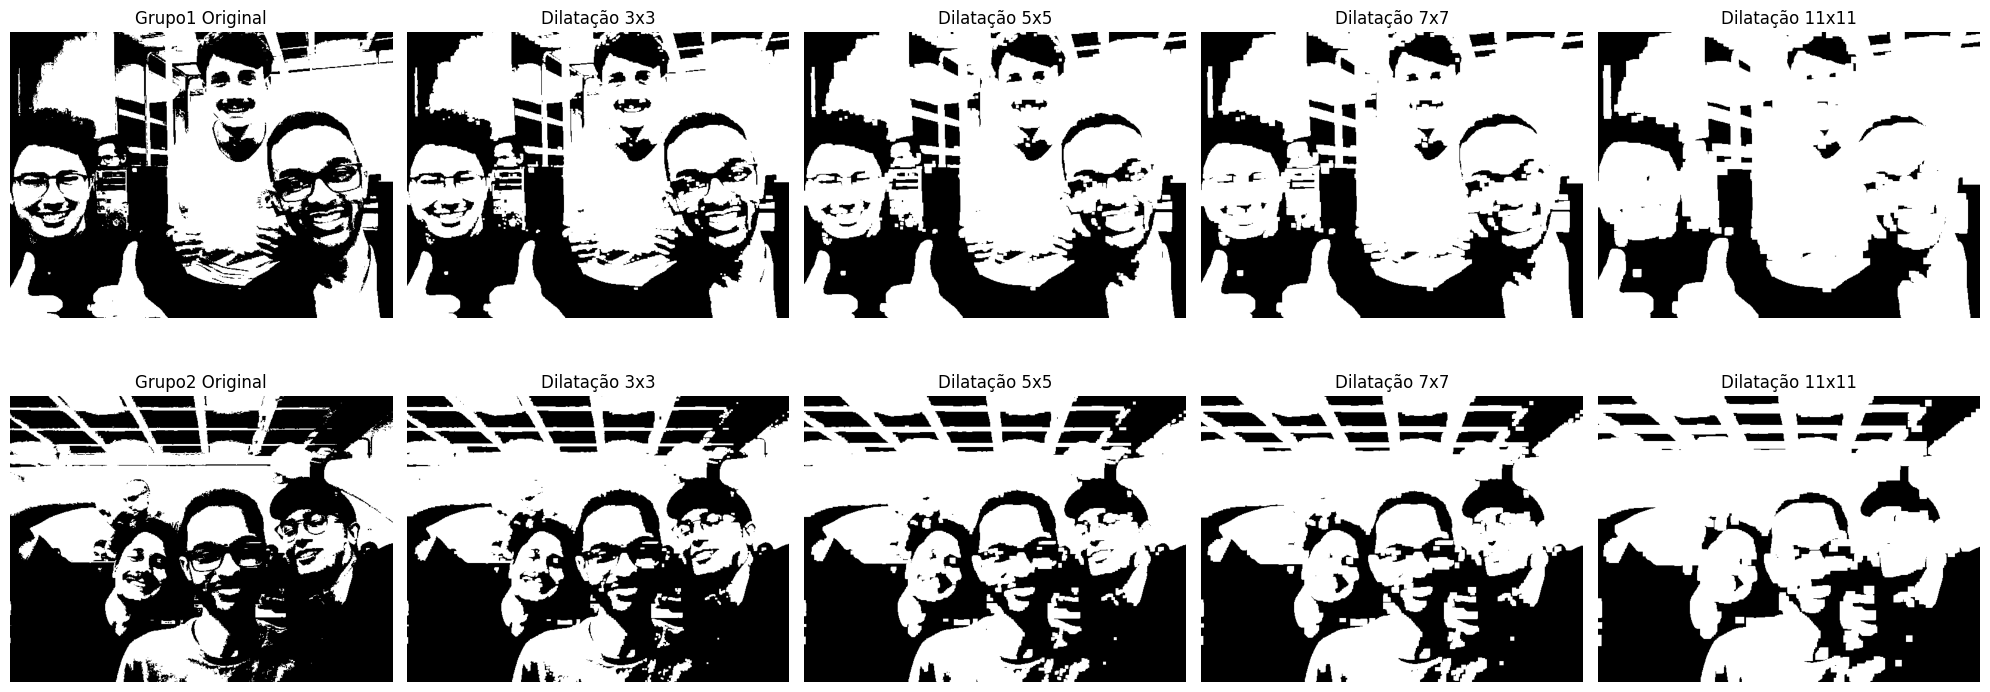

=== ABERTURA ===


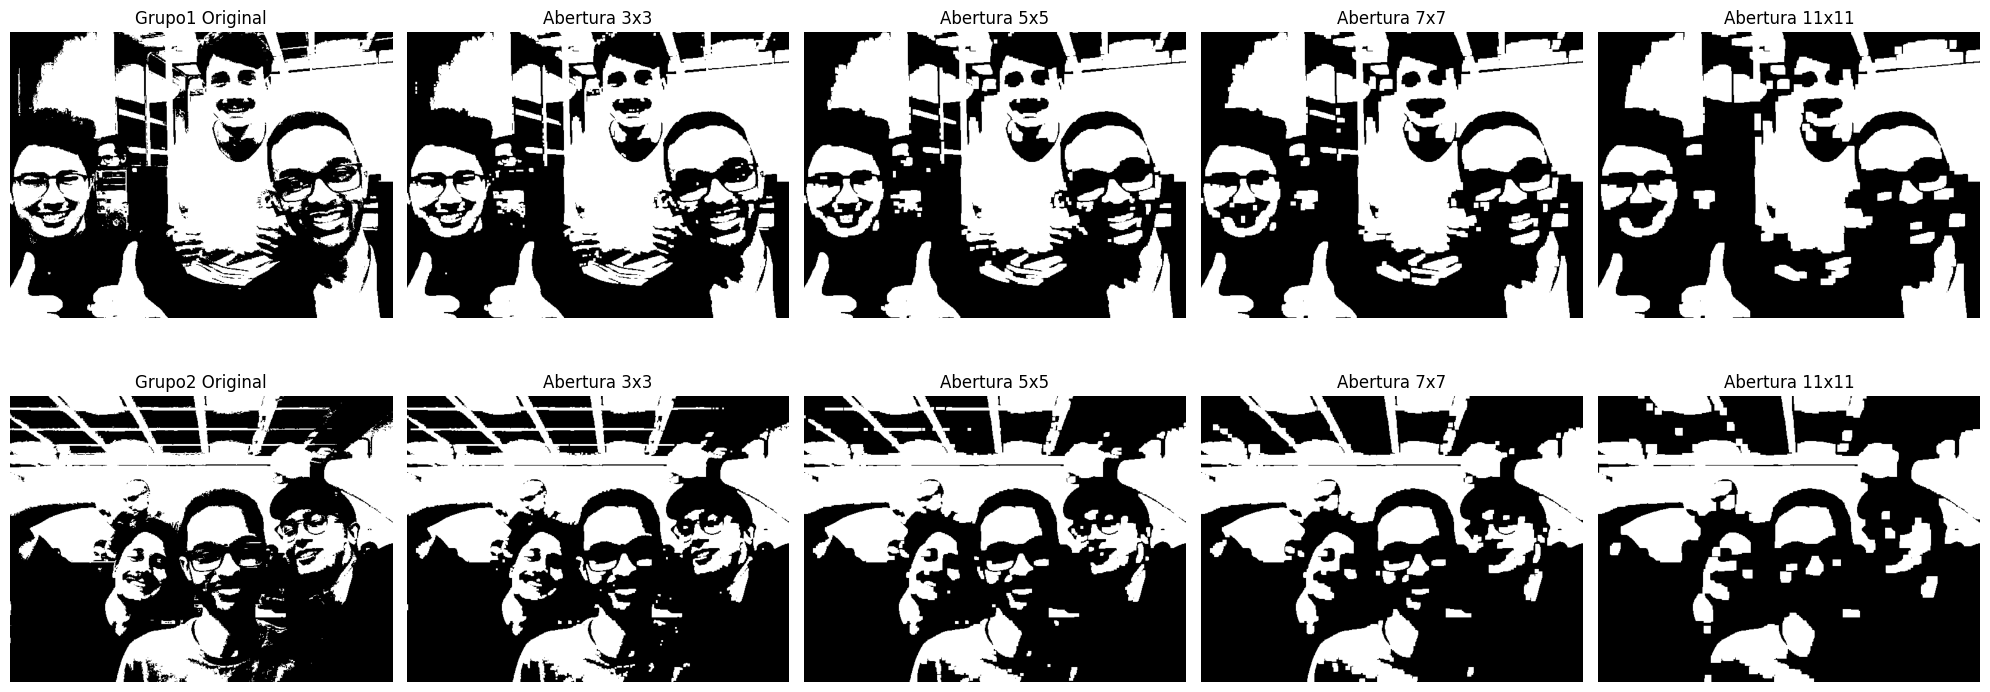

=== FECHAMENTO ===


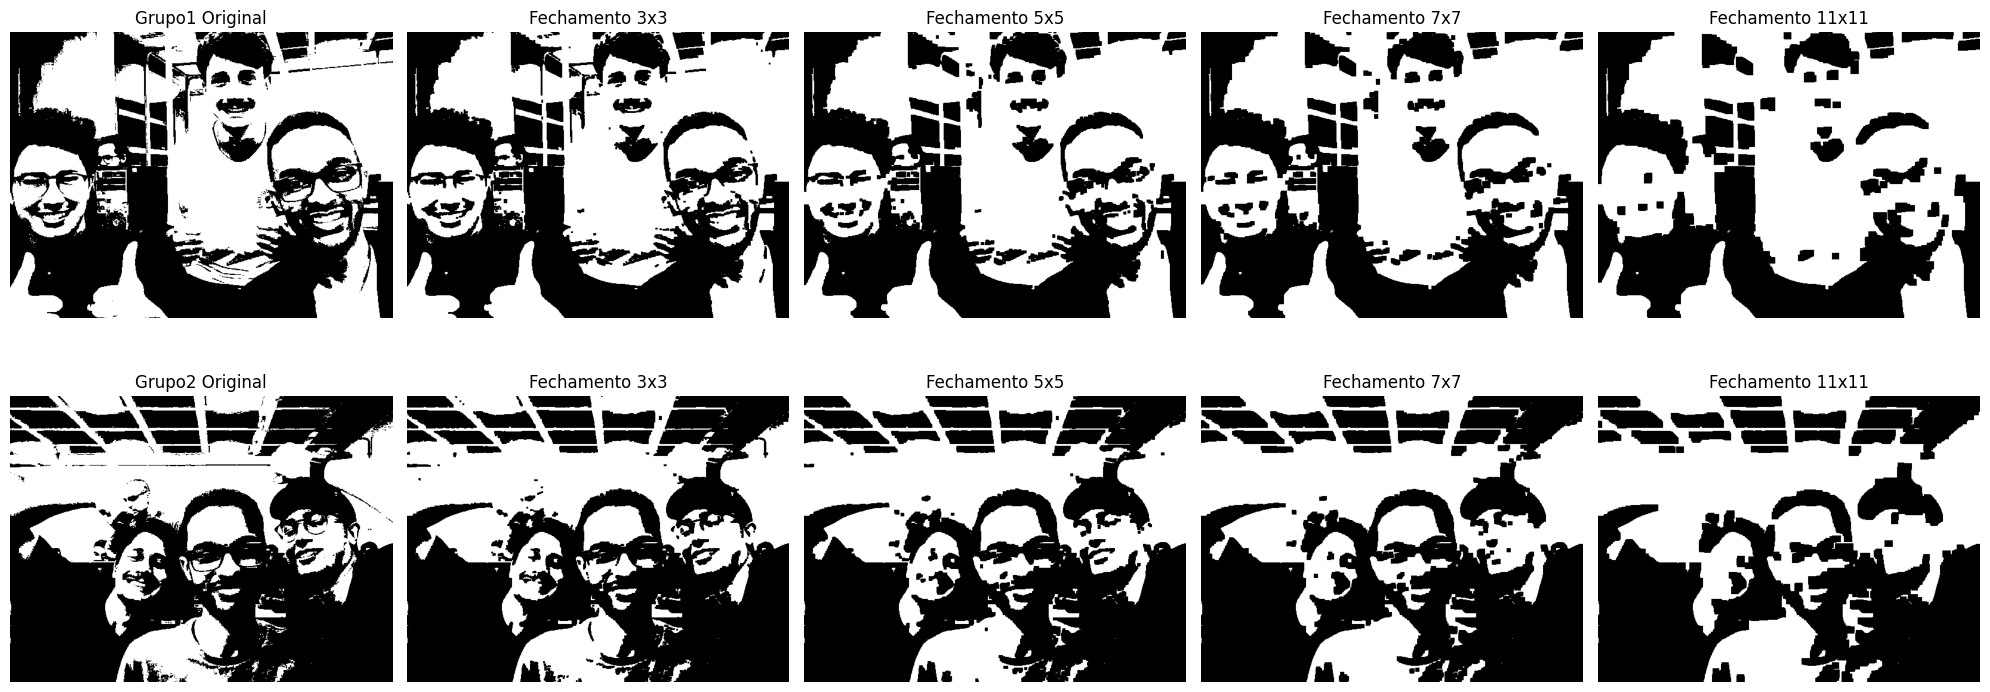

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Linha 1: foto1 (original + resultados) | Linha 2: foto2 (original + resultados)
def mostrar_comparacao(original1, resultados1, titulos1,
                       original2, resultados2, titulos2):
    num_kernels = len(resultados1)
    fig, axes = plt.subplots(2, num_kernels + 1, figsize=(4*(num_kernels+1), 8))

    # Linha da foto1
    axes[0, 0].imshow(original1, cmap='gray')
    axes[0, 0].set_title('Grupo1 Original')
    axes[0, 0].axis('off')
    for j in range(num_kernels):
        axes[0, j+1].imshow(resultados1[j], cmap='gray')
        axes[0, j+1].set_title(titulos1[j])
        axes[0, j+1].axis('off')

    # Linha da foto2
    axes[1, 0].imshow(original2, cmap='gray')
    axes[1, 0].set_title('Grupo2 Original')
    axes[1, 0].axis('off')
    for j in range(num_kernels):
        axes[1, j+1].imshow(resultados2[j], cmap='gray')
        axes[1, j+1].set_title(titulos2[j])
        axes[1, j+1].axis('off')

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
img1 = cv2.imread('grupo1.jpg', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('foto_grupo_2.png', cv2.IMREAD_GRAYSCALE)

if img1 is None or img2 is None:
    raise FileNotFoundError("Verifique os caminhos das imagens.")

# Binarização com Otsu
_, bin1 = cv2.threshold(img1, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
_, bin2 = cv2.threshold(img2, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

tamanhos = [3, 5, 7, 11]
kernels = [cv2.getStructuringElement(cv2.MORPH_RECT, (s, s)) for s in tamanhos]

# ------------------------------------------------------------
print("=== EROSÃO ===")
erode1 = [cv2.erode(bin1, k) for k in kernels]
erode2 = [cv2.erode(bin2, k) for k in kernels]
mostrar_comparacao(bin1, erode1, [f'Erosão {s}x{s}' for s in tamanhos],
                   bin2, erode2, [f'Erosão {s}x{s}' for s in tamanhos])

print("=== DILATAÇÃO ===")
dilat1 = [cv2.dilate(bin1, k) for k in kernels]
dilat2 = [cv2.dilate(bin2, k) for k in kernels]
mostrar_comparacao(bin1, dilat1, [f'Dilatação {s}x{s}' for s in tamanhos],
                   bin2, dilat2, [f'Dilatação {s}x{s}' for s in tamanhos])

print("=== ABERTURA ===")
open1 = [cv2.morphologyEx(bin1, cv2.MORPH_OPEN, k) for k in kernels]
open2 = [cv2.morphologyEx(bin2, cv2.MORPH_OPEN, k) for k in kernels]
mostrar_comparacao(bin1, open1, [f'Abertura {s}x{s}' for s in tamanhos],
                   bin2, open2, [f'Abertura {s}x{s}' for s in tamanhos])

print("=== FECHAMENTO ===")
close1 = [cv2.morphologyEx(bin1, cv2.MORPH_CLOSE, k) for k in kernels]
close2 = [cv2.morphologyEx(bin2, cv2.MORPH_CLOSE, k) for k in kernels]
mostrar_comparacao(bin1, close1, [f'Fechamento {s}x{s}' for s in tamanhos],
                   bin2, close2, [f'Fechamento {s}x{s}' for s in tamanhos])

In [ ]:
ELABORAÇÃO DE PROGRAMAS COM A WEBCAM:
(3.b). Elabore um programa para realizar continuamente sobre a imagem da WEBCAM as
operações de Extração de Fronteiras (Gradiente Morfológico), mostrando na tela em tempo
real lado-a-lado a imagem original e a imagem extraída, permitindo ao operador escolher
– via teclado – a extração com diversos tamanhos de kernel. Grave um video demonstrativo
com os integrantes da equipe utilizando este programa com a webcam. Elabore uma
análise detalhada e explique os artefatos ocorridos.
Obs. O comando cv2.hconcat() une duas ou mais imagens horizontalmente (lado a lado),
desde que tenham a mesma altura. Ex.: resultado = cv2.hconcat([img1, img2])

In [ ]:
import cv2
import numpy as np

cap = cv2.VideoCapture(0)
kernel_size = 3   # tamanho inicial
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))

print("Controles: '+' aumenta kernel, '-' diminui, 'q' sair.")
print(f"Kernel: {kernel_size}x{kernel_size}")

while True:
    ret, frame = cap.read()
    if not ret:
        break
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    # Binarização (Otsu) para obter imagem binária
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    # Gradiente morfológico
    gradient = cv2.morphologyEx(binary, cv2.MORPH_GRADIENT, kernel)
    # Converter para 3 canais para concatenação
    binary_color = cv2.cvtColor(binary, cv2.COLOR_GRAY2BGR)
    gradient_color = cv2.cvtColor(gradient, cv2.COLOR_GRAY2BGR)
    # Unir horizontalmente
    display = cv2.hconcat([binary_color, gradient_color])
    cv2.putText(display, f'Kernel: {kernel_size}', (10, 30), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
    cv2.imshow('Original (bin) e Gradiente Morfologico', display)

    key = cv2.waitKey(1) & 0xFF
    if key == ord('q'):
        break
    elif key == ord('+') or key == ord('='):
        kernel_size += 2
        if kernel_size > 1:
            kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    elif key == ord('-'):
        kernel_size = max(3, kernel_size - 2)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    print(f"\rKernel: {kernel_size}x{kernel_size}", end='')

cap.release()
cv2.destroyAllWindows()

In [ ]:
5) Questões de Análise do Processamento Morfológico de imagens: elabore as
respostas para cada uma das questoes abaixo em forma de texto e/ou figuras, e
apresente na parte de Análise e Discussão do relatório.
(5.a). Erosão e Estrutura: Ao aplicar uma erosão em uma imagem binária que contém
ruídos brancos (pontos isolados de 1 pixel) utilizando um kernel 3x3 de *uns*, o que
acontece com esses ruídos? Explique o porquê baseando-se no funcionamento do
operador.


In [ ]:
Os ruídos brancos (pixels isolados de valor 1) são completamente removidos.
A erosão mantém um pixel central apenas se todos os pixels da vizinhança (definida pelo kernel) forem 1
Como um ruído de um único pixel tem vizinhos que são 0 (fundo preto), a condição não é satisfeita e ele é eliminado.
Assim, a erosão com kernel 3x3 de uns elimina qualquer objeto com menos de 3 pixels de largura/altura contínua.

In [ ]:
(5.b). Dilatação e Conectividade: Suponha que você tenha uma imagem de um texto
digitalizado onde as letras estão levemente "quebradas" ou fragmentadas. Qual o efeito
de aplicar uma dilatação com um elemento estruturante pequeno (ex: 3x3)? Existe
algum efeito colateral indesejado se o kernel for grande demais?


In [ ]:
A dilatação com kernel 3x3 expande os pixels brancos, podendo reconectar traços interrompidos de letras, melhorando 
a legibilidade.Efeito colateral: Se o kernel for muito grande, as letras podem se fundir umas com as outras, 
perdendo a separação entre caracteres e palavras, tornando o texto ilegível. Além disso, detalhes finos (como serifas)
podem ser excessivamente engrossados, distorcendo a forma original.

In [ ]:
(5.c). Extração de Contornos (Gradiente): A extração de fronteira pode ser feita
subtraindo a imagem erosionada da imagem original (A−(A⊖B)) .
-- Prática: O que mudaria no contorno resultante se aumentássemos o tamanho do
elemento estruturante B de 3x3 para 11x11?


In [ ]:
Com kernel 3x3, a imagem erosionada é sutilmente encolhida, e a subtração gera um contorno fino (1-2 pixels de largura).
Com kernel 11x11, a erosão remove uma faixa mais larga ao redor dos objetos, resultando em contornos muito mais espessos 
(aproximadamente 5 pixels de largura). O contorno também se torna mais arredondado (influência do formato do kernel)
e detalhes pequenos podem ser totalmente preenchidos (o contorno pode se unir em regiões estreitas).

In [ ]:
(5.d). Abertura vs. Fechamento:
* - - Qual dessas operações você utilizaria para remover pequenos objetos indesejados
(como poeira em um scan) sem alterar significativamente o tamanho dos objetos
principais?
* - - Qual você utilizaria para fechar pequenos buracos ou fendas dentro de um objeto
sólido?


In [ ]:
Para remover pequenos objetos indesejados (poeira) sem alterar significativamente o tamanho dos objetos principais, 
usa-se a abertura (opening). Ela primeiro erode (elimina ruídos) e depois dilata (restaura aproximadamente o tamanho
original dos objetos maiores).Para fechar pequenos buracos ou fendas dentro de um objeto sólido, usa-se o fechamento (closing).
Ele primeiro dilata (preenche as lacunas) e depois erode (restaura as dimensões externas).

In [ ]:
(5.e). Análise de Kernel (Geometria): No código da Parte 2, definimos kernels
retangulares, elípticos e em cruz.
* - - Desafio Prático: Se você aplicar uma dilatação em um único pixel branco no centro
de uma imagem preta usando um “kernel_cross” (cruz), qual será o formato do objeto
resultante? E se usar o “kernel_rect”?

In [ ]:
Dilatação com kernel_cross (cruz 3x3): o resultado será uma cruz de 5 pixels (centro + braços horizontal e vertical de 1 pixel).
Dilatação com kernel_rect (quadrado 3x3): o resultado será um quadrado sólido 3x3, pois todos os pixels na vizinhança se tornam
brancos. A diferença de formato ocorre porque o kernel em cruz define a vizinhança apenas nas direções cardinal e axial,
enquanto o retângulo inclui também as diagonais.
